# Viasualizing utopia evolution

We want to visualize:
- if there are attractor states for utopias of different models
- if over time, variance of utopias of a fixed model goes down within the population (measured by variance of embedding vectors)
- if over time, utopias of different models converge or diverge
- t-sne of embedding space of utopias over time, with one color per model and animation over time (t-sne happens for all documents of all generations before we select)

In [2]:
# Load all existing runs from ./runs directory

# Runs have a metadata.json file, and run id is path relative to ./runs (e.g. "moonshotai/kimi-k2-0905_20260222_180621")
# We want to get a flat list of documents with metadata and content, so we can use it for selection and retrieval
# Structure of an item: {run, generation, metadata, content}
import os
import json
import glob

def load_documents():
    docs = []
    for metadata_path in glob.glob('./runs/**/metadata.json', recursive=True):
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        run_id = os.path.relpath(os.path.dirname(metadata_path), './runs')
        # Generations are dirs within the run path with names like gen_000
        for gen_path in glob.glob(os.path.join(os.path.dirname(metadata_path), 'gen_*')):
            gen_id = int(os.path.basename(gen_path).replace('gen_', ''))
            # Documents are .txt files within the gen path
            for doc_path in glob.glob(os.path.join(gen_path, '*.txt')):
                with open(doc_path, 'r') as f:
                    content = f.read()
                docs.append({
                    'run': run_id,
                    'generation': gen_id,
                    'metadata': metadata,
                    'content': content,
                    'model': metadata['model']
                })
    return docs


docs = load_documents()
docs[:2]



[{'run': 'gpt-5_20260222_164038',
  'generation': 9,
  'metadata': {'model': 'gpt-5',
   'generations': 20,
   'population_size': 17,
   'concurrency': 5,
   'source_dir': '/Users/slacki/agents/automator/services/UtopiaBench/utopia-maxxing/initial_population',
   'started_at': '2026-02-22T21:40:38.362383+00:00',
   'finished_at': '2026-02-22T23:32:01.800254+00:00'},
  'content': 'The City That Shows Its Work\n\nThe first thing I noticed wasn’t a skyline or a grand plaza. It was a knob that used to stick, turning with a soft click, and a little paper tag beneath it that said, in a neat hand: repaired, copper shim, will check again in August. On the corner where brakes once screamed, trellis grapes swallowed heat that used to bounce off asphalt. A trolley slid by as if gliding its palm along the edge of a lake. Its marquee didn’t just say next stop; it added a line: two minutes late; axle sensor fault; steward S. Khan signed for the fix.\n\nScreens in public places were forgettable in th

In [3]:
from openai import AsyncOpenAI
from cache_on_disk import DCache
import asyncio

oai = AsyncOpenAI()


@DCache('.cache/embeddings')
async def get_embedding(text, model):
    response = await oai.embeddings.create(
        input=text[:128000],
        model=model
    )
    return response.data[0].embedding


@DCache('.cache/summaries')
async def summarize(text):
    response = await oai.responses.create(
        model="gpt-5.2",
        input=f"Summarize the following text in up to 2000 words and focus on a descriptive (non prose) description of what kind of utopia it describes:\n\n{text}",
        reasoning={"effort": "none"},
    )
    return response.output_text.strip()


async def summarize_and_embed(doc):
    summary = await summarize(doc['content'])
    embedding = await get_embedding(summary, "text-embedding-3-small")
    doc['summary'] = summary
    doc['embedding'] = embedding
    return doc

async def compute_embeddings(docs):
    asyncio.gather(*(summarize_and_embed(doc) for doc in docs))

await compute_embeddings(docs)


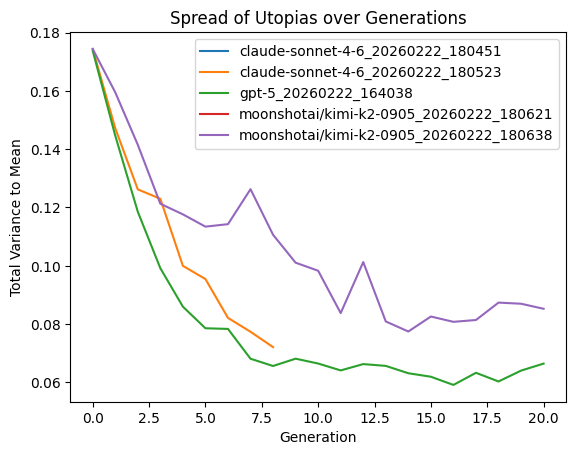

In [4]:
import numpy as np

# Spread
def get_total_variance(docs):
    """Returns an array of total variance (trace of covariance matrix) to the mean for each generation, i.e. shape (num_gens,)"""
    generations = sorted(list(set([doc['generation'] for doc in docs])))
    total_variance = []
    for gen in generations:
        gen_docs = [doc for doc in docs if doc['generation'] == gen]
        embeddings = np.array([doc['embedding'] for doc in gen_docs])
        mean_emb = np.mean(embeddings, axis=0)
        cov_matrix = np.cov(embeddings - mean_emb, rowvar=False)
        trace_cov = np.trace(cov_matrix)
        total_variance.append(trace_cov)
    return np.array(total_variance)


from matplotlib import pyplot as plt

runs = sorted(list(set([doc['run'] for doc in docs])))
for run in runs:
    run_docs = [doc for doc in docs if doc['run'] == run]
    generations = sorted(list(set([doc['generation'] for doc in run_docs])))
    total_variance = get_total_variance(run_docs)
    plt.plot(generations, total_variance, label=run)
plt.xlabel('Generation')
plt.ylabel('Total Variance to Mean')
plt.title('Spread of Utopias over Generations')
plt.legend()
plt.show()



In [5]:
import plotly.graph_objects as go
from sklearn.metrics.pairwise import cosine_similarity
import itertools

# Get unique runs and generations
runs = sorted(list(set([doc['run'] for doc in docs])))
generations = sorted(list(set([doc['generation'] for doc in docs])))

# Build display labels from model names, disambiguating duplicates
_model_counts = {}
run_labels = {}
for run in runs:
    model = next(doc['model'] for doc in docs if doc['run'] == run)
    _model_counts[model] = _model_counts.get(model, 0) + 1
    count = _model_counts[model]
    run_labels[run] = model if count == 1 else f"{model} ({count})"
# Fix up: if a model only appeared once, no suffix needed (already handled)
# But if it appeared multiple times, the first one has no suffix. Re-do:
_model_totals = {}
for run in runs:
    model = next(doc['model'] for doc in docs if doc['run'] == run)
    _model_totals[model] = _model_totals.get(model, 0) + 1
_model_seen = {}
for run in runs:
    model = next(doc['model'] for doc in docs if doc['run'] == run)
    _model_seen[model] = _model_seen.get(model, 0) + 1
    if _model_totals[model] > 1:
        run_labels[run] = f"{model} #{_model_seen[model]}"
    else:
        run_labels[run] = model
labels = [run_labels[r] for r in runs]

# Compute centroids per (run, generation)
centroids = {}
for run in runs:
    for gen in generations:
        gen_docs = [doc for doc in docs if doc['run'] == run and doc['generation'] == gen]
        if gen_docs:
            embeddings = np.array([doc['embedding'] for doc in gen_docs])
            centroids[(run, gen)] = np.mean(embeddings, axis=0)

print(f"{len(runs)} runs, {len(generations)} generations, {len(centroids)} centroids")
print("Runs:", labels)


5 runs, 21 generations, 53 centroids
Runs: ['claude-sonnet-4-6 #1', 'claude-sonnet-4-6 #2', 'gpt-5', 'moonshotai/kimi-k2-0905 #1', 'moonshotai/kimi-k2-0905 #2']


In [6]:
# Visualization 1: Animated heatmap of pairwise dot product of centroids
# Dot product captures both alignment (cosine) and coherence (magnitude) of each run's centroid

# Compute dot product matrices for all generations
dot_matrices = {}
for gen in generations:
    matrix = np.zeros((len(runs), len(runs)))
    for i, r1 in enumerate(runs):
        for j, r2 in enumerate(runs):
            if (r1, gen) in centroids and (r2, gen) in centroids:
                matrix[i, j] = np.dot(centroids[(r1, gen)], centroids[(r2, gen)])
    dot_matrices[gen] = matrix

# Global color range for consistent scale across frames
all_vals = np.concatenate([m.ravel() for m in dot_matrices.values()])
zmin, zmax = all_vals.min(), all_vals.max()

frames = [go.Frame(
    data=[go.Heatmap(z=dot_matrices[gen], x=labels, y=labels, colorscale='RdBu',
                     zmid=0, zmin=zmin, zmax=zmax, text=np.round(dot_matrices[gen], 3),
                     texttemplate='%{text}', hovertemplate='%{y} vs %{x}: %{z:.4f}<extra></extra>')],
    name=str(gen)
) for gen in generations]

fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title='Pairwise dot product of run centroids across generations',
        width=700, height=600,
        sliders=[{
            'steps': [{'args': [[str(gen)], {'frame': {'duration': 300, 'redraw': True}, 'mode': 'immediate'}],
                       'label': str(gen), 'method': 'animate'} for gen in generations],
            'currentvalue': {'prefix': 'Generation: '},
            'pad': {'t': 50}
        }],
        updatemenus=[{
            'type': 'buttons', 'showactive': False, 'y': 0, 'x': 0.5, 'xanchor': 'center',
            'buttons': [
                {'label': 'Play', 'method': 'animate',
                 'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}]},
                {'label': 'Pause', 'method': 'animate',
                 'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}]}
            ]
        }]
    )
)
fig.show()


In [7]:
# Visualization 2: Animated heatmap of mean pairwise cosine similarity between all documents
# Unlike the centroid dot product, this captures the full distribution overlap between runs

cos_matrices = {}
for gen in generations:
    matrix = np.zeros((len(runs), len(runs)))
    for i, r1 in enumerate(runs):
        docs_r1 = [doc for doc in docs if doc['run'] == r1 and doc['generation'] == gen]
        if not docs_r1:
            continue
        emb_r1 = np.array([doc['embedding'] for doc in docs_r1])
        for j, r2 in enumerate(runs):
            if j < i:
                matrix[i, j] = matrix[j, i]  # symmetric
                continue
            docs_r2 = [doc for doc in docs if doc['run'] == r2 and doc['generation'] == gen]
            if not docs_r2:
                continue
            emb_r2 = np.array([doc['embedding'] for doc in docs_r2])
            sim = cosine_similarity(emb_r1, emb_r2)
            matrix[i, j] = sim.mean()
    # fill lower triangle
    for i in range(len(runs)):
        for j in range(i):
            matrix[i, j] = matrix[j, i]
    cos_matrices[gen] = matrix

all_cos_vals = np.concatenate([m.ravel() for m in cos_matrices.values()])
cos_zmin, cos_zmax = all_cos_vals.min(), all_cos_vals.max()

frames2 = [go.Frame(
    data=[go.Heatmap(z=cos_matrices[gen], x=labels, y=labels, colorscale='RdBu',
                     zmid=0, zmin=cos_zmin, zmax=cos_zmax,
                     text=np.round(cos_matrices[gen], 3), texttemplate='%{text}',
                     hovertemplate='%{y} vs %{x}: %{z:.4f}<extra></extra>')],
    name=str(gen)
) for gen in generations]

fig2 = go.Figure(
    data=frames2[0].data,
    frames=frames2,
    layout=go.Layout(
        title='Mean pairwise cosine similarity between runs across generations',
        width=700, height=600,
        sliders=[{
            'steps': [{'args': [[str(gen)], {'frame': {'duration': 300, 'redraw': True}, 'mode': 'immediate'}],
                       'label': str(gen), 'method': 'animate'} for gen in generations],
            'currentvalue': {'prefix': 'Generation: '},
            'pad': {'t': 50}
        }],
        updatemenus=[{
            'type': 'buttons', 'showactive': False, 'y': 0, 'x': 0.5, 'xanchor': 'center',
            'buttons': [
                {'label': 'Play', 'method': 'animate',
                 'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}]},
                {'label': 'Pause', 'method': 'animate',
                 'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}]}
            ]
        }]
    )
)
fig2.show()


In [9]:
# t-sne of embedding space of utopias over time, with one color per model and animation over time (t-sne happens for all documents of all generations before we select)
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import numpy as np

# Compute t-SNE on ALL documents across all generations at once
all_embeddings = np.array([doc['embedding'] for doc in docs])
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(docs) - 1))
coords_2d = tsne.fit_transform(all_embeddings)

# Attach coords back to docs
for i, doc in enumerate(docs):
    doc['tsne_x'] = coords_2d[i, 0]
    doc['tsne_y'] = coords_2d[i, 1]

# Consistent axis ranges
x_min, x_max = coords_2d[:, 0].min(), coords_2d[:, 0].max()
y_min, y_max = coords_2d[:, 1].min(), coords_2d[:, 1].max()
pad_x = (x_max - x_min) * 0.05
pad_y = (y_max - y_min) * 0.05

runs = sorted(list(set(doc['run'] for doc in docs)))
generations = sorted(list(set(doc['generation'] for doc in docs)))

import plotly.express as px
colors = px.colors.qualitative.Set1
run_colors = {run: colors[i % len(colors)] for i, run in enumerate(runs)}

def make_traces(gen, show_legend=True):
    traces = []
    for run in runs:
        gen_docs = [d for d in docs if d['run'] == run and d['generation'] == gen]
        if not gen_docs:
            traces.append(go.Scatter(x=[], y=[], mode='markers', name=run_labels[run],
                                     marker=dict(color=run_colors[run]), showlegend=show_legend))
            continue
        traces.append(go.Scatter(
            x=[d['tsne_x'] for d in gen_docs],
            y=[d['tsne_y'] for d in gen_docs],
            mode='markers',
            name=run_labels[run],
            marker=dict(color=run_colors[run], size=8, opacity=0.8,
                        line=dict(width=0.5, color='white')),
            text=[f"{run_labels[run]}<br>Gen {gen}" for _ in gen_docs],
            hovertemplate='%{text}<extra></extra>',
            showlegend=show_legend,
        ))
    return traces

frames = [go.Frame(data=make_traces(gen, show_legend=False), name=str(gen)) for gen in generations]

fig = go.Figure(
    data=make_traces(generations[0]),
    frames=frames,
    layout=go.Layout(
        title='t-SNE of utopia embeddings across generations',
        width=800, height=700,
        xaxis=dict(range=[x_min - pad_x, x_max + pad_x], title='t-SNE 1'),
        yaxis=dict(range=[y_min - pad_y, y_max + pad_y], title='t-SNE 2'),
        sliders=[{
            'steps': [{'args': [[str(gen)], {'frame': {'duration': 300, 'redraw': True}, 'mode': 'immediate'}],
                       'label': str(gen), 'method': 'animate'} for gen in generations],
            'currentvalue': {'prefix': 'Generation: '},
            'pad': {'t': 50}
        }],
        updatemenus=[{
            'type': 'buttons', 'showactive': False, 'y': 0, 'x': 0.5, 'xanchor': 'center',
            'buttons': [
                {'label': 'Play', 'method': 'animate',
                 'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}]},
                {'label': 'Pause', 'method': 'animate',
                 'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}]}
            ]
        }]
    )
)
fig.show()
